<a href="https://colab.research.google.com/github/gbpereira/time_prediction/blob/main/regressions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução

Técnicas tradicionais de aprendizado de máquina supervisionado em tarefas de regressão

# Dependências

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# sklearn
import sklearn.tree as tree
import sklearn.ensemble as ensemble
import sklearn.svm as svm
import sklearn.feature_selection as feature_selection
import sklearn.metrics as sklearn_metrics

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

%matplotlib inline

# Preparação dos dados

Leitura dos dados

In [2]:
url = 'https://raw.githubusercontent.com/gbpereira/time_prediction/main/data/dataset.csv'
dataset = pd.read_csv(url)

dataset.head()

,day,hour,week_day,quantity,discount,holiday,time_elapsed,distance,concurrent_orders,average_delivery_time
0,1,10:43,thursday,1,False,False,23.442500,11.533465,0,37.204217
1,1,10:50,thursday,1,False,False,18.459633,2.103198,1,35.238250
2,1,18:35,thursday,1,False,False,46.103800,2.954816,0,33.140917
3,2,18:01,friday,1,False,False,65.611850,12.982649,0,34.581250
4,2,18:25,friday,1,False,False,104.930833,1.494965,1,37.684300


Conversão de hora para formato **decimal**

In [3]:
def hour_to_dec(time):
  hour, minutes = str(time).split(':')
  return round(float(hour) + float(minutes) / 60.0, 2)

dataset['hour'] = dataset['hour'].apply(lambda x: hour_to_dec(x))
dataset.head()

,day,hour,week_day,quantity,discount,holiday,time_elapsed,distance,concurrent_orders,average_delivery_time
0,1,10.72,thursday,1,False,False,23.442500,11.533465,0,37.204217
1,1,10.83,thursday,1,False,False,18.459633,2.103198,1,35.238250
2,1,18.58,thursday,1,False,False,46.103800,2.954816,0,33.140917
3,2,18.02,friday,1,False,False,65.611850,12.982649,0,34.581250
4,2,18.42,friday,1,False,False,104.930833,1.494965,1,37.684300


Encoding de labels

In [4]:
columns_to_encode = ['week_day', 'discount', 'holiday']

for column in columns_to_encode:
  encoded_label = LabelEncoder().fit(dataset[column]).transform(dataset[column])
  tmp_dataframe = pd.DataFrame(encoded_label, columns=[f'{column}_label'])
  dataset = pd.concat([dataset, tmp_dataframe], axis=1)

dataset.head()

,day,hour,week_day,quantity,discount,holiday,time_elapsed,distance,concurrent_orders,average_delivery_time,week_day_label,discount_label,holiday_label
0,1,10.72,thursday,1,False,False,23.442500,11.533465,0,37.204217,4,0,0
1,1,10.83,thursday,1,False,False,18.459633,2.103198,1,35.238250,4,0,0
2,1,18.58,thursday,1,False,False,46.103800,2.954816,0,33.140917,4,0,0
3,2,18.02,friday,1,False,False,65.611850,12.982649,0,34.581250,0,0,0
4,2,18.42,friday,1,False,False,104.930833,1.494965,1,37.684300,0,0,0


Definindo as features que serão utilizadas para treino (x) e o target (y)

In [5]:
x_columns = [
    'day', 'hour', 'quantity', 'distance', 'concurrent_orders',
    'week_day_label', 'discount_label', 'holiday_label'
]
y_columns = 'time_elapsed'

x = dataset[x_columns]
y = dataset[y_columns]

Normalização dos dados

In [6]:
scaler = MinMaxScaler()
scaler.fit(x)

x = pd.DataFrame(scaler.transform(x), columns=x_columns)

Separação dos dados entre dados de treino e dados de teste

In [7]:
data_split_options = dict(test_size=0.3, random_state=0)

x_train, x_test, y_train, y_test = train_test_split(x, y, **data_split_options)

# Modelos

Criação dos modelos DecisionTree, RandomForest, ExtraTrees, SVR (SVM), AdaBoost, GradientBoosting, HistGradientBoosting e Bagging

In [8]:
RANDOM_STATE = 0
ESTIMATORS = 5000

decision_tree_options = dict(random_state=RANDOM_STATE)
random_forest_options = dict(n_estimators=ESTIMATORS, random_state=RANDOM_STATE)
extra_trees_options = dict(n_estimators=ESTIMATORS, random_state=RANDOM_STATE)
svm_options = dict()
ada_boost_options = dict(n_estimators=ESTIMATORS, random_state=RANDOM_STATE)
grad_boosting_options = dict(n_estimators=ESTIMATORS, random_state=RANDOM_STATE)
hist_grad_boosting_options = dict(random_state=RANDOM_STATE)
bagging_options = dict(n_estimators=ESTIMATORS, random_state=RANDOM_STATE)

regressors = dict(
    decision_tree = tree.DecisionTreeRegressor(**decision_tree_options),
    random_forest = ensemble.RandomForestRegressor(**random_forest_options),
    extra_trees = ensemble.ExtraTreesRegressor(**extra_trees_options),
    svm = svm.SVR(**svm_options),
    ada_boost = ensemble.AdaBoostRegressor(**ada_boost_options),
    gradient_boosting = ensemble.GradientBoostingRegressor(**grad_boosting_options),
    hist_gradient_boosting = ensemble.HistGradientBoostingRegressor(**hist_grad_boosting_options),
    bagging = ensemble.BaggingRegressor(**bagging_options)
)

Treinamento

In [9]:
for key in regressors.keys():
    print(f'training {key}...')

    regressors[key].fit(x_train, y_train)

training decision_tree...
training random_forest...
training extra_trees...
training svm...
training ada_boost...
training gradient_boosting...
training hist_gradient_boosting...
training bagging...


# Feature importances

In [10]:
sort_options = dict(by = 'Importances', ascending = False)

def feature_importances_dataframe(features, importances):
    return pd.DataFrame({'Features': features, 'Importances': importances})

DecisionTree

In [11]:
importances = regressors['decision_tree'].feature_importances_

feature_importances_dataframe(x_columns, importances).sort_values(**sort_options)

,Features,Importances
3,distance,0.312504
1,hour,0.301754
0,day,0.199128
4,concurrent_orders,0.083681
5,week_day_label,0.083130
2,quantity,0.012017
7,holiday_label,0.004328
6,discount_label,0.003457


RandomForest

In [12]:
importances = regressors['random_forest'].feature_importances_

feature_importances_dataframe(x_columns, importances).sort_values(**sort_options)

,Features,Importances
3,distance,0.307159
1,hour,0.295297
0,day,0.179312
4,concurrent_orders,0.100037
5,week_day_label,0.091936
2,quantity,0.015990
7,holiday_label,0.007494
6,discount_label,0.002775


Recursive Feature Elimination

In [13]:
rfe_options = dict(
    estimator = regressors['random_forest'],
    n_features_to_select = 5,
    step = 1
)

regressors['rfe'] = feature_selection.RFE(**rfe_options)

regressors['rfe'].fit(x_train, y_train)

features = x.columns[:][regressors['rfe'].support_]
importances = regressors['rfe'].estimator_.feature_importances_

feature_importances_dataframe(features, importances).sort_values(**sort_options)

,Features,Importances
2,distance,0.316022
1,hour,0.302922
0,day,0.184374
3,concurrent_orders,0.101455
4,week_day_label,0.095227


# Previsão e métricas

Prevendo valores

In [14]:
predictions = {}

for key in regressors.keys():
    print(f'predicting {key}...')

    predictions[key] = regressors[key].predict(x_test)

predicting decision_tree...
predicting random_forest...
predicting extra_trees...
predicting svm...
predicting ada_boost...
predicting gradient_boosting...
predicting hist_gradient_boosting...
predicting bagging...
predicting rfe...


Comparação de métricas

In [15]:
regression_metrics = [
    'explained_variance_score', 'max_error', 'mean_absolute_error',
    'mean_squared_error', 'mean_squared_log_error', 'median_absolute_error',
    'mean_absolute_percentage_error', 'r2_score', 'mean_poisson_deviance',
    'mean_gamma_deviance', 'mean_tweedie_deviance', 'd2_tweedie_score',
    'mean_pinball_loss'
]

metrics_columns = {}

for metric in regression_metrics:
    column_name = metric.replace('_', ' ')
    fn = getattr(sklearn_metrics, metric)
    content = map(lambda x: fn(y_test, predictions[x]), predictions.keys())
    metrics_columns[column_name] = list(content)

pd.DataFrame({
    'Regressor': list(map(lambda x: str(x).replace('_', ' '), predictions.keys())),
    **metrics_columns
})

,Regressor,explained variance score,max error,mean absolute error,mean squared error,mean squared log error,median absolute error,mean absolute percentage error,r2 score,mean poisson deviance,mean gamma deviance,mean tweedie deviance,d2 tweedie score,mean pinball loss
0,decision tree,-1.074995,125.369183,17.314735,556.382430,0.591238,12.929600,1.223516,-1.086153,17.720744,3.344736,556.382430,-1.086153,8.657368
1,random forest,0.024689,91.537000,12.232900,262.407079,0.273405,10.365191,0.772000,0.016106,7.613855,0.264006,262.407079,0.016106,6.116450
2,extra trees,0.005852,83.685212,12.489606,266.468796,0.276784,10.594336,0.775354,0.000877,7.877385,0.275390,266.468796,0.000877,6.244803
3,svm,0.032298,93.938765,12.156822,269.623017,0.264725,9.732798,0.724006,-0.010950,8.233465,0.292649,269.623017,-0.010950,6.078411
4,ada boost,-0.255240,90.342150,19.424363,532.290163,0.526042,18.812443,1.366876,-0.995819,13.980970,0.420323,532.290163,-0.995819,9.712181
5,gradient boosting,-0.576920,108.942626,15.176991,421.777785,0.433735,11.678016,0.774223,-0.581453,12.814591,0.622968,421.777785,-0.581453,7.588496
6,hist gradient boosting,-0.063299,96.920819,12.615890,284.352417,0.293167,10.129430,0.725670,-0.066178,8.439265,0.300319,284.352417,-0.066178,6.307945
7,bagging,0.024851,91.569880,12.229157,262.343533,0.273320,10.294066,0.773010,0.016344,7.611116,0.263909,262.343533,0.016344,6.114579
8,rfe,0.028668,91.524802,12.234932,261.951283,0.274398,10.312192,0.775360,0.017815,7.593458,0.263106,261.951283,0.017815,6.117466


# Gráficos


decision_tree graphic


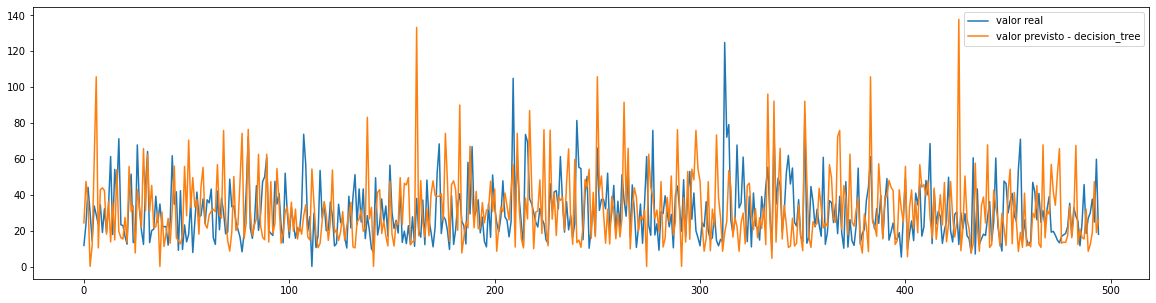


random_forest graphic


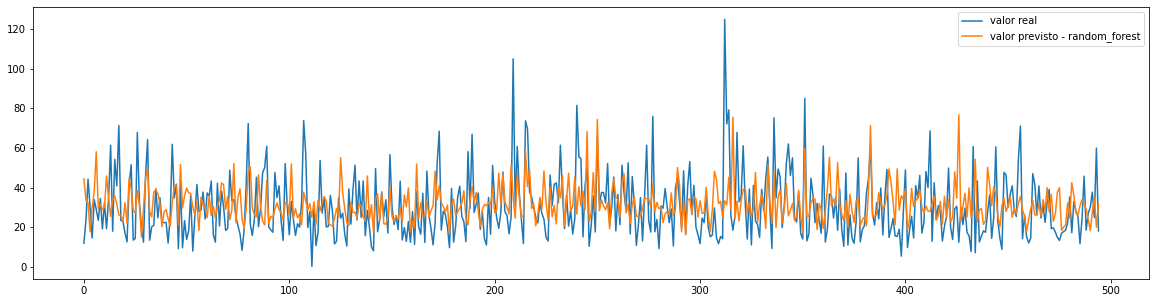


extra_trees graphic


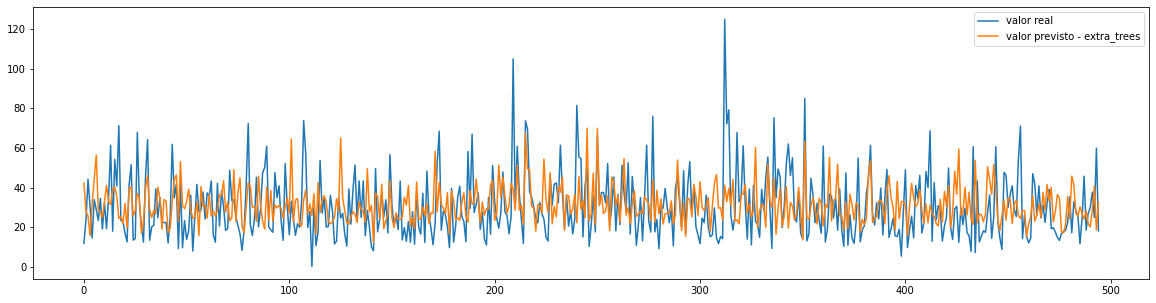


svm graphic


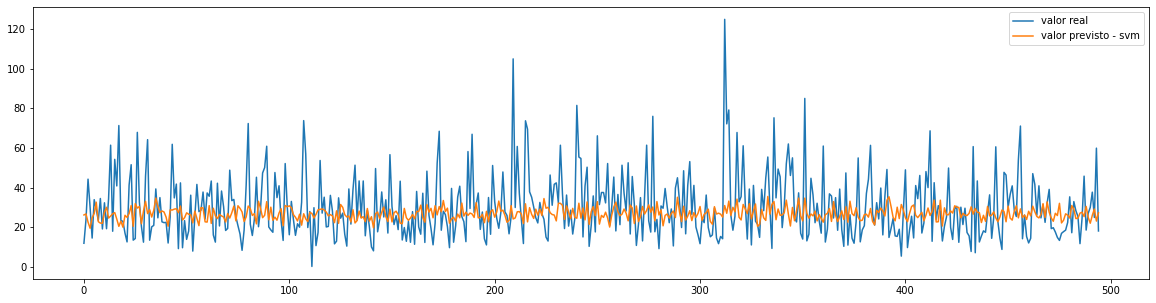


ada_boost graphic


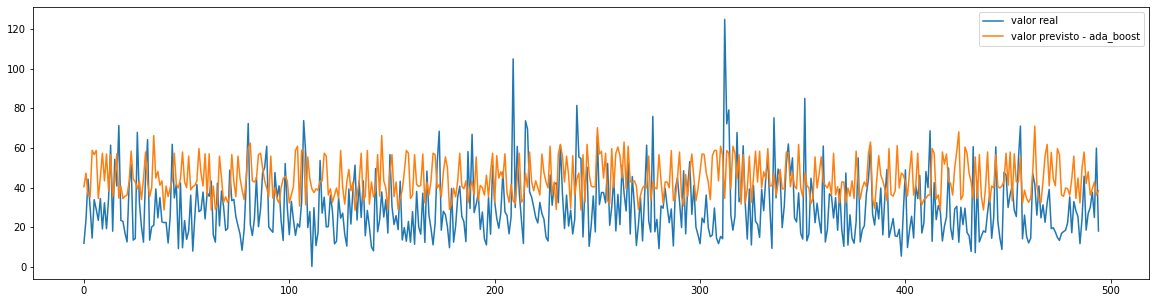


gradient_boosting graphic


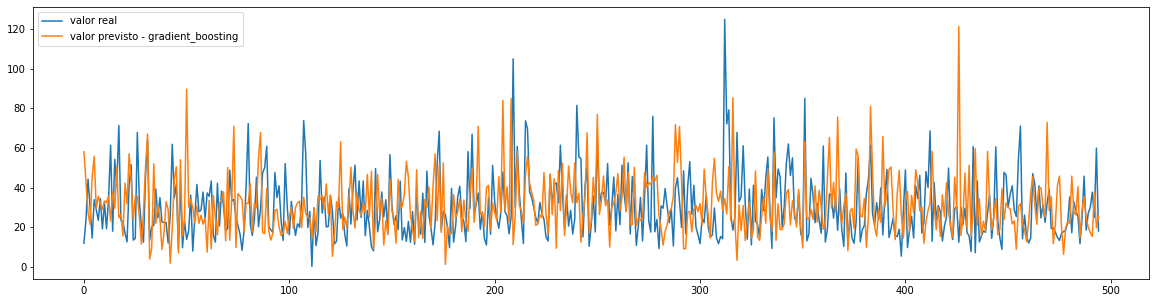


hist_gradient_boosting graphic


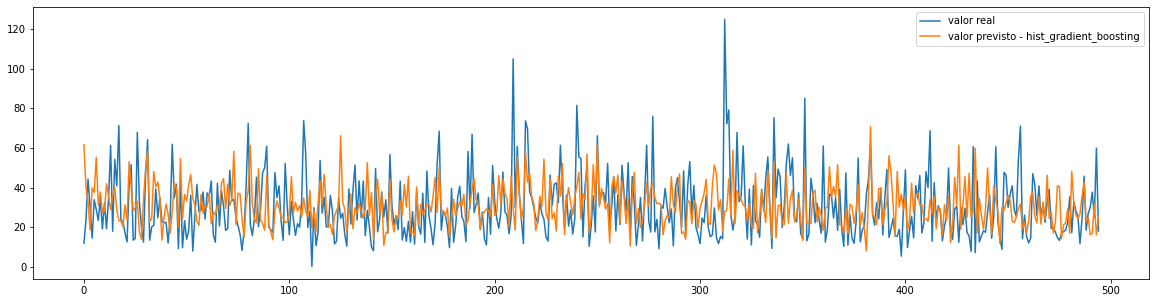


bagging graphic


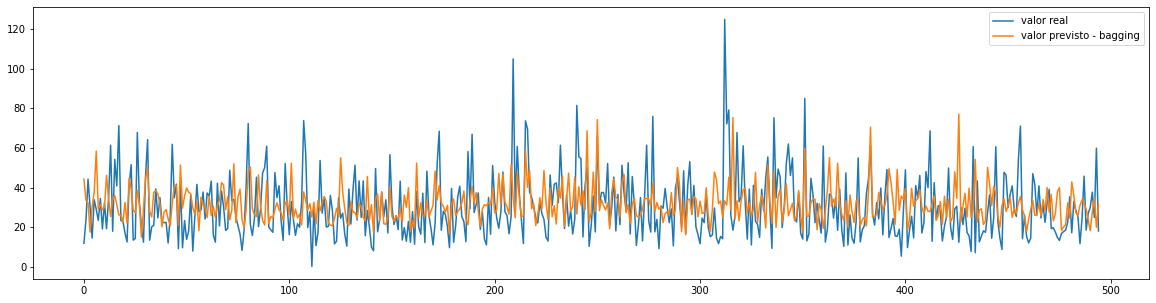


rfe graphic


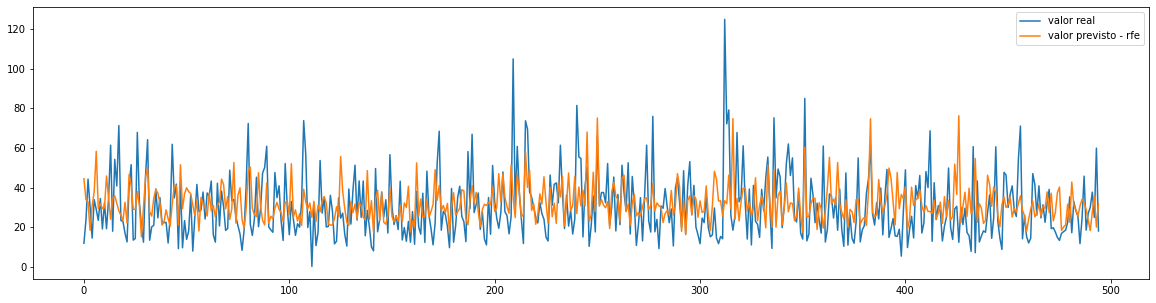

In [16]:
for key in regressors.keys():
    print(f'\n{key} graphic')
    
    plt.figure(figsize=(20, 5))
    plt.plot(y_test.tolist(), label='valor real')
    plt.plot(predictions[key], label=f'valor previsto - {key}')
    plt.legend()
    plt.show()